# Tree Structure Diagnosis

## Setup

In [2]:
library(duckdb)
library(DBI)
library(dplyr)
library(synthpop)
library(ggplot2)
library(tidyr)
library(rpart)
library(rpart.plot)

source("config.R")

read_sql <- function(name) {
  paste(readLines(file.path("sql", paste0(name, ".sql"))), collapse = "\n")
}

con <- dbConnect(duckdb())

dbExecute(con, sprintf("CREATE VIEW diagnoses_icd AS SELECT * FROM read_csv_auto('%s/hosp/diagnoses_icd.csv.gz')", DATA_DIR))
dbExecute(con, sprintf("CREATE VIEW icustays AS SELECT * FROM read_csv_auto('%s/icu/icustays.csv.gz')", DATA_DIR))
dbExecute(con, sprintf("CREATE VIEW patients AS SELECT * FROM read_csv_auto('%s/hosp/patients.csv.gz')", DATA_DIR))
dbExecute(con, sprintf("CREATE VIEW admissions AS SELECT * FROM read_csv_auto('%s/hosp/admissions.csv.gz')", DATA_DIR))
dbExecute(con, sprintf("CREATE VIEW labevents AS SELECT * FROM read_csv_auto('%s/hosp/labevents.csv.gz')", DATA_DIR))

duckdb keeps downloaded extensions and secrets in a temporary directory:
ℹ /var/folders/5d/pvxmh0mx4f124ss1c7t2ymk00000gn/T//Rtmpe34N1f/duckdb
This is removed when the R session ends.
• Extensions are re-downloaded each session.
• Secrets are lost.
ℹ Run duckdb(shared_home = TRUE) (or create ~/.duckdb) to keep them (suitable for most users).
ℹ Run duckdb(shared_home = FALSE) to accept the temporary directory (and silence this message).
ℹ See ?duckdb_storage for details and alternatives.


[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

## Rebuild Pool

In [3]:
# cohort_base.sql and creatinine_firstday.sql are shared with
# mimic-fidelity-analysis.ipynb so both notebooks build the pool the same way.
cohort_base <- dbGetQuery(con, read_sql("cohort_base"))

creatinine_firstday <- dbGetQuery(con, read_sql("creatinine_firstday"))
CAP <- quantile(creatinine_firstday$creatinine_max, 0.995, na.rm = TRUE)
creatinine_firstday$creatinine_max_capped <- pmin(creatinine_firstday$creatinine_max, CAP)

preprocess <- function(df) {
  # cohort_base.sql carries five comorbidities and the stay timestamps; this
  # notebook diagnoses three, so the rest are dropped to keep `pool` the same
  # shape the results below were computed on.
  df <- df %>% select(-stay_id, -hadm_id, -subject_id, -intime, -outtime,
                      -renal_failure, -hypertension)

  df$gender               <- factor(df$gender)
  df$admission_type       <- factor(df$admission_type)
  df$insurance            <- factor(df$insurance)
  df$hospital_expire_flag <- factor(df$hospital_expire_flag, levels = c(0, 1))
  df$chf                  <- factor(df$chf,      levels = c(0, 1))
  df$diabetes             <- factor(df$diabetes, levels = c(0, 1))
  df$copd                 <- factor(df$copd,     levels = c(0, 1))

  return(df)
}

flat_table <- cohort_base %>%
  left_join(creatinine_firstday %>% select(stay_id, creatinine_max_capped), by = "stay_id")

flat_table <- preprocess(flat_table)

pool <- flat_table %>% filter(!is.na(creatinine_max_capped))

str(pool)

'data.frame':	70954 obs. of  10 variables:
 $ los                  : num  1.64 1.64 2.48 4.7 1.14 ...
 $ gender               : Factor w/ 2 levels "F","M": 2 2 2 2 2 2 2 2 1 2 ...
 $ anchor_age           : num  61 64 91 43 68 77 40 56 68 43 ...
 $ admission_type       : Factor w/ 9 levels "AMBULATORY OBSERVATION",..: 6 6 6 6 9 9 6 6 6 8 ...
 $ insurance            : Factor w/ 3 levels "Medicaid","Medicare",..: 3 2 2 1 3 3 2 3 2 3 ...
 $ hospital_expire_flag : Factor w/ 2 levels "0","1": 1 1 1 2 1 1 1 1 1 1 ...
 $ chf                  : Factor w/ 2 levels "0","1": 1 2 2 1 1 2 1 1 1 1 ...
 $ diabetes             : Factor w/ 2 levels "0","1": 1 2 1 1 1 2 1 1 1 2 ...
 $ copd                 : Factor w/ 2 levels "0","1": 1 1 1 1 2 1 1 1 1 1 ...
 $ creatinine_max_capped: num  1.1 3.7 1.2 1 0.6 1.1 1.6 2.7 0.5 0.9 ...


### inspect_tree()

In [4]:
inspect_tree <- function(comorbidity_col, k, pool, n_fixed = 500, seed = 1, permute = FALSE) {
  pos_pool <- pool %>% filter(.data[[comorbidity_col]] == "1")
  neg_pool <- pool %>% filter(.data[[comorbidity_col]] == "0")

  set.seed(seed)
  sub <- bind_rows(
    pos_pool[sample(nrow(pos_pool), k), ],
    neg_pool[sample(nrow(neg_pool), n_fixed - k), ]
  )

  # permutation null: shuffle comorbidity to keep the marginal positive count k
  # but destroy any real association with the outcome / other predictors
  if (permute) sub[[comorbidity_col]] <- sample(sub[[comorbidity_col]])

  formula_str <- paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ", comorbidity_col)
  # Mirror synthpop::syn.cart's rpart settings (minbucket = 5, cp = 1e-08) so the
  # diagnostic tree reflects the generator rather than a more permissive proxy.
  tree <- rpart(as.formula(formula_str), data = sub, method = "class",
                control = rpart.control(minsplit = 20, minbucket = 5, cp = 1e-08))

  list(sub = sub, tree = tree)
}

### tree_one_seed()

In [5]:
tree_one_seed <- function(comorbidity_col, k, pool, n_fixed = 500, seed, permute = FALSE) {
  fit <- inspect_tree(comorbidity_col, k, pool, n_fixed, seed = seed, permute = permute)
  fr  <- fit$tree$frame

  split_vars <- as.character(fr$var)
  nodes      <- as.integer(rownames(fr))
  idx        <- which(split_vars == comorbidity_col)
  depths     <- floor(log2(nodes[idx]))

  # GLM reference, fit on the identical subsample (permuted as well when
  # permute = TRUE). The LRT drops the main effect and the interaction together,
  # so it asks the tree's question, does this variable earn a place at all,
  # rather than a question the tree was never posed.
  sub_num <- fit$sub
  sub_num[[comorbidity_col]] <- as.numeric(as.character(sub_num[[comorbidity_col]]))

  f_full <- as.formula(paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ",
                              comorbidity_col, " + ", comorbidity_col, ":creatinine_max_capped"))
  f_null <- as.formula("hospital_expire_flag ~ anchor_age + creatinine_max_capped")

  g_full <- suppressWarnings(glm(f_full, data = sub_num, family = binomial))
  g_null <- suppressWarnings(glm(f_null, data = sub_num, family = binomial))
  glm_p  <- suppressWarnings(anova(g_null, g_full, test = "LRT")$`Pr(>Chi)`[2])

  cf   <- coef(g_full)
  term <- grep(paste0("^(creatinine_max_capped:", comorbidity_col, "|",
                      comorbidity_col, ":creatinine_max_capped)$"), names(cf), value = TRUE)

  data.frame(
    comorbidity  = comorbidity_col,
    count        = k,
    rep          = seed,
    permute      = permute,
    used         = length(idx) > 0,
    n_como_split = length(idx),
    first_depth  = if (length(idx)) min(depths) else NA_real_,
    first_n      = if (length(idx)) fr$n[idx[which.min(depths)]] else NA_real_,
    n_splits     = sum(split_vars != "<leaf>"),
    max_depth    = max(floor(log2(nodes))),
    glm_est      = if (length(term)) unname(cf[term[1]]) else NA_real_,
    glm_p        = glm_p
  )
}

## Count Sweep: Split Rate vs Positive Count

Each `(comorbidity, count)` pair is also refit after shuffling `comorbidity`
within `sub`: same marginal count `k`, but the association with the outcome is
destroyed. This separates two explanations for a low `split_rate` — real signal
too weak at low `k` to win a split, versus the comorbidity simply not getting
picked in a tree that only grows about five splits regardless.

Read the observed curve against the null:

- **observed ≈ null** → nothing is being detected above chance; any rise there
  is a class-balance artifact
- **observed ≫ null** → the split rate reflects real information

In [6]:
counts <- c(5, 10, 20, 40, 80, 150, 250)
M      <- 100

tree_grid <- expand.grid(
  comorbidity = c("chf", "diabetes", "copd"),
  count       = counts,
  permute     = c(FALSE, TRUE),
  stringsAsFactors = FALSE
)

tree_results <- lapply(seq_len(nrow(tree_grid)), function(i) {
  como <- tree_grid$comorbidity[i]
  k    <- tree_grid$count[i]
  perm <- tree_grid$permute[i]
  lapply(seq_len(M), function(r) {
    tree_one_seed(como, k, pool, seed = k * 1000 + r, permute = perm)
  }) %>% bind_rows()
}) %>% bind_rows()

tree_rate <- tree_results %>%
  group_by(comorbidity, count, permute) %>%
  summarise(
    split_rate  = mean(used),
    glm_rate    = mean(glm_p < 0.05, na.rm = TRUE),
    med_depth   = median(first_depth, na.rm = TRUE),
    med_n       = median(first_n,     na.rm = TRUE),
    med_nsplits = median(n_splits),
    .groups = "drop"
  ) %>%
  arrange(comorbidity, count, permute)

print(tree_rate, n = Inf)

# A tibble: 42 × 8
   comorbidity count permute split_rate glm_rate med_depth med_n med_nsplits
   <chr>       <dbl> <lgl>        <dbl>    <dbl>     <dbl> <dbl>       <dbl>
 1 chf             5 FALSE         0        0.05      NA    NA             4
 2 chf             5 TRUE          0        0.04      NA    NA             4
 3 chf            10 FALSE         0.04     0.1        1   107             5
 4 chf            10 TRUE          0.01     0.1        1   118             5
 5 chf            20 FALSE         0.08     0.09       2    88             4
 6 chf            20 TRUE          0.01     0.06       1   110             4
 7 chf            40 FALSE         0.21     0.08       3    57             5
 8 chf            40 TRUE          0.07     0.06       3    71             5
 9 chf            80 FALSE         0.21     0.05       2    72             5
10 chf            80 TRUE          0.23     0.11       3    65             5
11 chf           150 FALSE         0.28     0.04       2 

In [7]:
tree_results %>%
  select(comorbidity, count, rep, permute, used) %>%
  pivot_wider(names_from = permute, values_from = used,
              names_prefix = "perm_") %>%
  group_by(comorbidity, count) %>%
  summarise(
    only_obs  = sum(perm_FALSE & !perm_TRUE),
    only_perm = sum(!perm_FALSE & perm_TRUE),
    p = binom.test(c(only_obs, only_perm))$p.value,
    .groups = "drop"
  )

comorbidity,count,only_obs,only_perm,p
<chr>,<dbl>,<int>,<int>,<dbl>
chf,5,0,0,1.000000000
chf,10,4,1,0.375000000
chf,20,8,1,0.039062500
chf,40,18,4,0.004343510
chf,80,15,17,0.860050066
chf,150,15,15,1.000000000
chf,250,17,20,0.742829359
copd,5,1,0,1.000000000
copd,10,4,1,0.375000000


In [8]:
tree_rate %>%
  select(comorbidity, count, permute, split_rate) %>%
  pivot_wider(names_from = permute, values_from = split_rate,
              names_prefix = "perm_") %>%
  mutate(excess = perm_FALSE - perm_TRUE) %>%
  arrange(comorbidity, count)

comorbidity,count,perm_FALSE,perm_TRUE,excess
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
chf,5,0.00,0.00,0.00
chf,10,0.04,0.01,0.03
chf,20,0.08,0.01,0.07
chf,40,0.21,0.07,0.14
chf,80,0.21,0.23,-0.02
chf,150,0.28,0.28,0.00
chf,250,0.27,0.30,-0.03
copd,5,0.01,0.00,0.01
copd,10,0.04,0.01,0.03


### One Trend Test Instead of Twenty-One Cell Tests

Testing each cell on its own wastes the grid. Every cell carries 100 paired
replicates, most of them concordant and therefore uninformative, so the
discordant counts that drive each test are small and only one or two cells
reach significance after correction.

A conditional logistic model fits the whole grid at once. Each replicate is
its own stratum, which is exactly the pairing the per-cell McNemar tests use,
so the observed and shuffled runs are compared within the same 500 rows.
`count` is constant inside a stratum and so drops out, but its interaction
with `permute` is identified: that coefficient says whether the gap between
the real column and the shuffled one widens or narrows as the count grows.

In [9]:
library(survival)

# observed as 0/1 rather than logical: a logical gets factor contrasts, which
# produce two interaction terms whose within-stratum values are exact negatives
# of each other, so one comes back NA and the output is hard to read.
# log2k is centred at k = 40, the first count where the widths are comparable,
# so the main effect is the log odds ratio there rather than at k = 1.
paired <- tree_results %>%
  mutate(pair     = paste(comorbidity, rep, sep = "_"),
         observed = as.integer(!permute),
         log2k_c  = log2(count) - log2(40))

# strata(pair) conditions on the replicate, so only discordant pairs contribute,
# the same information the per-cell binom.test used
m_trend <- clogit(used ~ observed + observed:log2k_c + strata(pair), data = paired)
summary(m_trend)

Call:
coxph(formula = Surv(1 + 0 * used, used) ~ observed + observed:log2k_c + 
    strata(pair), data = paired, method = "exact")

  n= 4200, number of events= 585 

                     coef exp(coef) se(coef)      z Pr(>|z|)    
observed          0.68621   1.98618  0.15200  4.515 6.34e-06 ***
observed:log2k_c -0.20492   0.81471  0.08385 -2.444   0.0145 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                 exp(coef) exp(-coef) lower .95 upper .95
observed            1.9862     0.5035    1.4745    2.6754
observed:log2k_c    0.8147     1.2274    0.6912    0.9602

Concordance= 0.603  (se = 0.034 )
Likelihood ratio test= 23.81  on 2 df,   p=7e-06
Wald test            = 22.29  on 2 df,   p=1e-05
Score (logrank) test = 23.3  on 2 df,   p=9e-06


In [10]:
# same model per comorbidity, to check the pooled result is not carried by one
m_by_como <- lapply(c("chf", "diabetes", "copd"), function(c0) {
  fit <- clogit(used ~ observed + observed:log2k_c + strata(pair),
                data = paired %>% filter(comorbidity == c0))
  cf  <- summary(fit)$coefficients
  data.frame(comorbidity = c0,
             term = rownames(cf),
             coef = round(cf[, "coef"], 3),
             or   = round(exp(cf[, "coef"]), 2),
             se   = round(cf[, "se(coef)"], 3),
             p    = signif(cf[, "Pr(>|z|)"], 3),
             row.names = NULL)
}) %>% bind_rows()
print(m_by_como)

# the fitted advantage at each count, which is what the table above encodes
cf <- coef(m_trend)
tibble(count = counts) %>%
  mutate(log2k_c = log2(count) - log2(40),
         log_or  = cf["observed"] + cf["observed:log2k_c"] * log2k_c,
         odds_ratio = round(exp(log_or), 2)) %>%
  select(count, odds_ratio)

  comorbidity             term   coef   or    se       p
1         chf         observed  0.918 2.50 0.285 0.00130
2         chf observed:log2k_c -0.481 0.62 0.157 0.00217
3    diabetes         observed  0.218 1.24 0.289 0.45000
4    diabetes observed:log2k_c  0.195 1.22 0.161 0.22700
5        copd         observed  0.791 2.21 0.245 0.00127
6        copd observed:log2k_c -0.262 0.77 0.137 0.05600


count,odds_ratio
<dbl>,<dbl>
5,3.67
10,2.99
20,2.44
40,1.99
80,1.62
150,1.34
250,1.16


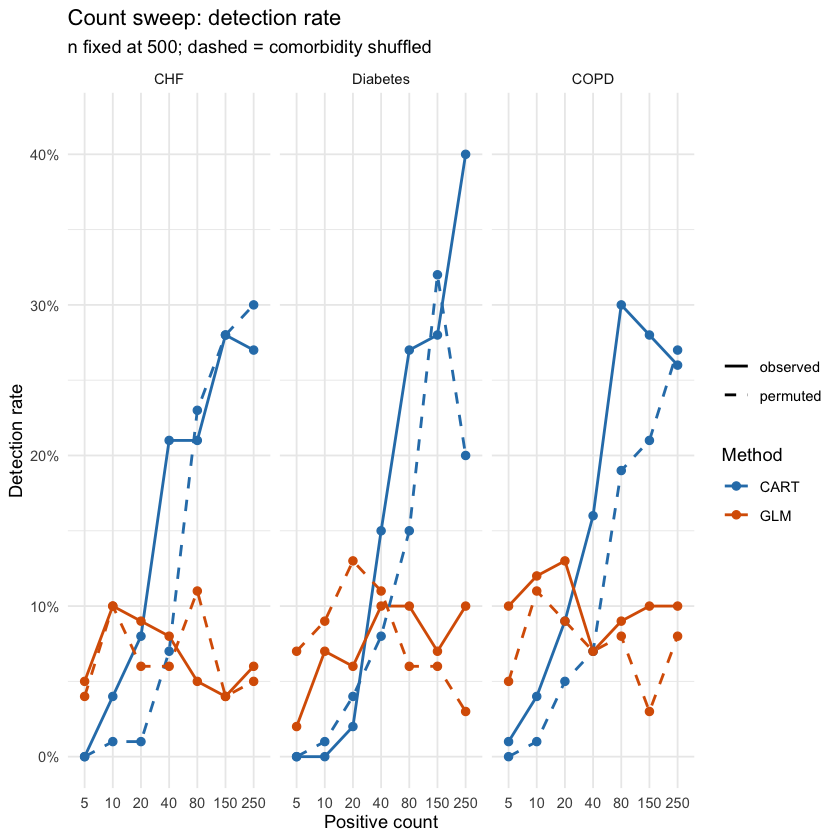

In [11]:
detect_long <- tree_rate %>%
  select(comorbidity, count, permute, CART = split_rate, GLM = glm_rate) %>%
  pivot_longer(c(CART, GLM), names_to = "method", values_to = "detect_rate") %>%
  mutate(comorbidity = factor(comorbidity, levels = c("chf", "diabetes", "copd"),
                              labels = c("CHF", "Diabetes", "COPD")))

p_count_detect <- ggplot(detect_long, aes(x = factor(count), y = detect_rate,
                        color = method, linetype = permute,
                        group = interaction(method, permute))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~ comorbidity) +
  scale_y_continuous(limits = c(0, 0.42), labels = scales::percent) +
  scale_color_manual(values = c(CART = "#2c7fb8", GLM = "#d95f02")) +
  scale_linetype_manual(values = c("FALSE" = "solid", "TRUE" = "dashed"),
                        labels = c("FALSE" = "observed", "TRUE" = "permuted")) +
  labs(title = "Count sweep: detection rate",
       subtitle = "n fixed at 500; dashed = comorbidity shuffled",
       x = "Positive count", y = "Detection rate",
       color = "Method", linetype = NULL) +
  theme_minimal()
p_count_detect

ggsave("../figures/tree_count_detect.png", p_count_detect,
       width = 6.5, height = 3.4, dpi = 150)

## Firth Arm: Separation or Thin Information

The sweeps call a fit **divergent** when the coefficient runs past a cutoff,
which lumps two different things together: a likelihood with no interior
maximum (separation), and a finite estimate that happens to be large.

Firth's penalized likelihood removes the first without touching the second.
It always returns a finite estimate, so if the divergence threshold at
`k = 80` is about separation it should disappear under `logistf`; if it
survives, the threshold is about how much information the stratum carries.

This runs on the real subsamples only. No `syn()` call is involved, so it is
cheap: the same draw loop the tree diagnosis already uses, with two extra
fits per replicate.

In [12]:
library(logistf)
library(detectseparation)

firth_one_seed <- function(comorbidity_col, k, pool, n_fixed = 500, seed) {
  pos_pool <- pool %>% filter(.data[[comorbidity_col]] == "1")
  neg_pool <- pool %>% filter(.data[[comorbidity_col]] == "0")

  # identical draw to inspect_tree() and run_one_trial(), same seed convention,
  # so a replicate here is the same 500 rows as everywhere else
  set.seed(seed)
  sub <- bind_rows(
    pos_pool[sample(nrow(pos_pool), k), ],
    neg_pool[sample(nrow(neg_pool), n_fixed - k), ]
  )
  sub[[comorbidity_col]] <- as.numeric(as.character(sub[[comorbidity_col]]))

  f <- as.formula(paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ",
                         comorbidity_col, " + ", comorbidity_col, ":creatinine_max_capped"))

  # terms() reorders the interaction, so match either spelling. glm, logistf and
  # detect_separation all name it the same way, so one pattern serves all three.
  pat <- paste0("^(creatinine_max_capped:", comorbidity_col, "|",
                comorbidity_col, ":creatinine_max_capped)$")
  pick <- function(v) {
    nm <- grep(pat, names(v), value = TRUE)
    if (length(nm)) unname(v[nm[1]]) else NA_real_
  }

  ml     <- suppressWarnings(glm(f, data = sub, family = binomial))
  ml_est <- pick(coef(ml))

  # separation in the interaction term specifically, not anywhere in the model:
  # a separated main effect says nothing about the coefficient under study
  sep    <- suppressWarnings(
              glm(f, data = sub, family = binomial, method = "detect_separation"))
  sep_cf <- unlist(sep$coefficients)
  sep_int <- pick(sep_cf)
  separated_any <- any(is.infinite(sep_cf))
  separated_int <- !is.na(sep_int) && is.infinite(sep_int)

  fr        <- suppressWarnings(logistf(f, data = sub))
  firth_est <- pick(fr$coefficients)

  data.frame(
    comorbidity   = comorbidity_col,
    count         = k,
    rep           = seed,
    separated_int = separated_int,
    separated_any = separated_any,
    ml_est        = ml_est,
    firth_est     = firth_est
  )
}

In [13]:
firth_results <- lapply(counts, function(k) {
  lapply(c("chf", "diabetes", "copd"), function(como) {
    lapply(seq_len(M), function(r) {
      firth_one_seed(como, k, pool, seed = k * 1000 + r)
    }) %>% bind_rows()
  }) %>% bind_rows()
}) %>% bind_rows()

firth_rate <- firth_results %>%
  group_by(comorbidity, count) %>%
  summarise(
    pct_sep_int    = mean(separated_int),
    pct_sep_any    = mean(separated_any),
    pct_ml_diverge = mean(!is.na(ml_est)    & abs(ml_est)    > EXPLODE_THRESHOLD),
    pct_fr_diverge = mean(!is.na(firth_est) & abs(firth_est) > EXPLODE_THRESHOLD),
    ml_median      = median(ml_est[abs(ml_est) <= EXPLODE_THRESHOLD], na.rm = TRUE),
    firth_median   = median(firth_est, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(comorbidity, count)

print(firth_rate, n = Inf, width = Inf)

# A tibble: 21 × 8
   comorbidity count pct_sep_int pct_sep_any pct_ml_diverge pct_fr_diverge
   <chr>       <dbl>       <dbl>       <dbl>          <dbl>          <dbl>
 1 chf             5        0.64        0.64           0.27           0.11
 2 chf            10        0.39        0.39           0.18           0.03
 3 chf            20        0.06        0.06           0.06           0.02
 4 chf            40        0           0              0              0   
 5 chf            80        0           0              0              0   
 6 chf           150        0           0              0              0   
 7 chf           250        0           0              0              0   
 8 copd            5        0.76        0.76           0.34           0.14
 9 copd           10        0.31        0.31           0.3            0.09
10 copd           20        0.11        0.11           0.13           0.04
11 copd           40        0           0              0              0   
12 cop

## Size Sweep: Split Rate vs Sample Size

The count sweep runs the comorbidity column from 1% positive to 50%, which is
why its permutation null rises: a balanced binary variable is easy to split on
whether or not it carries signal. This sweep moves balance the other way, `k`
held at 20 while `n` runs 250 to 4000, so the positive share falls from 8% to
0.5%. If the balance reading is right, the null has to fall here — a prediction
the count sweep alone cannot test.

Two confounds move with `n` and neither is signal, so read `excess` rather than
`split_rate`:

- `cp = 1e-08` barely prunes, so trees grow with `n`, and `used` gets easier to
  satisfy on both sides
- `minbucket = 5` is an absolute floor; at fixed `k` the stratum stays 20 rows
  but its share of the table shrinks

`early_rate` is reported alongside as a check, counting only replicates where
the comorbidity wins a split at depth 2 or shallower.

In [15]:
k_fixed <- 20
sizes   <- c(250, 500, 1000, 2000, 4000)

tree_grid_size <- expand.grid(
  comorbidity = c("chf", "diabetes", "copd"),
  n_fixed     = sizes,
  permute     = c(FALSE, TRUE),
  stringsAsFactors = FALSE
)

tree_size_results <- lapply(seq_len(nrow(tree_grid_size)), function(i) {
  como <- tree_grid_size$comorbidity[i]
  n    <- tree_grid_size$n_fixed[i]
  perm <- tree_grid_size$permute[i]
  lapply(seq_len(M), function(r) {
    # same seed convention as run_size_sweep() in mimic-fidelity-analysis.ipynb,
    # so the duplicated cell (k = 20, n = 500) is independent of the count sweep
    tree_one_seed(como, k_fixed, pool, n_fixed = n,
                  seed = n * 100 + k_fixed * 1000 + r, permute = perm) %>%
      mutate(n_fixed = n)
  }) %>% bind_rows()
}) %>% bind_rows()

tree_size_rate <- tree_size_results %>%
  group_by(comorbidity, n_fixed, permute) %>%
  summarise(
    split_rate  = mean(used),
    early_rate  = mean(!is.na(first_depth) & first_depth <= 2),
    glm_rate    = mean(glm_p < 0.05, na.rm = TRUE),
    med_depth   = median(first_depth, na.rm = TRUE),
    med_n       = median(first_n,     na.rm = TRUE),
    med_nsplits = median(n_splits),
    .groups = "drop"
  ) %>%
  arrange(comorbidity, n_fixed, permute)

print(tree_size_rate, n = Inf, width = Inf)

# A tibble: 30 × 9
   comorbidity n_fixed permute split_rate early_rate glm_rate med_depth med_n
   <chr>         <dbl> <lgl>        <dbl>      <dbl>    <dbl>     <dbl> <dbl>
 1 chf             250 FALSE         0.05       0.04     0.06       1    43  
 2 chf             250 TRUE          0.03       0.02     0.12       2    44  
 3 chf             500 FALSE         0.04       0.02     0.1        2.5  46.5
 4 chf             500 TRUE          0.02       0.01     0.12       2.5  87.5
 5 chf            1000 FALSE         0.14       0.04     0.06       4   105  
 6 chf            1000 TRUE          0.02       0.02     0.13       2   192. 
 7 chf            2000 FALSE         0.06       0.03     0.1        3   212. 
 8 chf            2000 TRUE          0.01       0        0.1        3   302  
 9 chf            4000 FALSE         0.07       0.02     0.08       3   483  
10 chf            4000 TRUE          0          0        0.06      NA    NA  
11 copd            250 FALSE         0.06    

In [16]:
tree_size_rate %>%
  select(comorbidity, n_fixed, permute, split_rate, early_rate, med_nsplits) %>%
  pivot_wider(names_from = permute,
              values_from = c(split_rate, early_rate, med_nsplits),
              names_prefix = "perm_") %>%
  mutate(excess       = split_rate_perm_FALSE - split_rate_perm_TRUE,
         excess_early = early_rate_perm_FALSE - early_rate_perm_TRUE) %>%
  arrange(comorbidity, n_fixed) %>%
  print(n = Inf, width = Inf)

# A tibble: 15 × 10
   comorbidity n_fixed split_rate_perm_FALSE split_rate_perm_TRUE
   <chr>         <dbl>                 <dbl>                <dbl>
 1 chf             250                  0.05                 0.03
 2 chf             500                  0.04                 0.02
 3 chf            1000                  0.14                 0.02
 4 chf            2000                  0.06                 0.01
 5 chf            4000                  0.07                 0   
 6 copd            250                  0.06                 0.08
 7 copd            500                  0.06                 0.01
 8 copd           1000                  0.08                 0.04
 9 copd           2000                  0.06                 0.02
10 copd           4000                  0.04                 0.03
11 diabetes        250                  0.07                 0.02
12 diabetes        500                  0.08                 0.04
13 diabetes       1000                  0.07            

In [17]:
tree_size_results %>%
  select(comorbidity, n_fixed, rep, permute, used) %>%
  pivot_wider(names_from = permute, values_from = used,
              names_prefix = "perm_") %>%
  group_by(comorbidity, n_fixed) %>%
  summarise(
    only_obs  = sum(perm_FALSE & !perm_TRUE),
    only_perm = sum(!perm_FALSE & perm_TRUE),
    p = binom.test(c(only_obs, only_perm))$p.value,
    .groups = "drop"
  ) %>%
  print(n = Inf, width = Inf)

# A tibble: 15 × 5
   comorbidity n_fixed only_obs only_perm       p
   <chr>         <dbl>    <int>     <int>   <dbl>
 1 chf             250        5         3 0.727  
 2 chf             500        4         2 0.687  
 3 chf            1000       13         1 0.00183
 4 chf            2000        6         1 0.125  
 5 chf            4000        7         0 0.0156 
 6 copd            250        6         8 0.791  
 7 copd            500        6         1 0.125  
 8 copd           1000        7         3 0.344  
 9 copd           2000        6         2 0.289  
10 copd           4000        4         3 1      
11 diabetes        250        5         0 0.0625 
12 diabetes        500        7         3 0.344  
13 diabetes       1000        7         2 0.180  
14 diabetes       2000       12         2 0.0129 
15 diabetes       4000        9         1 0.0215 


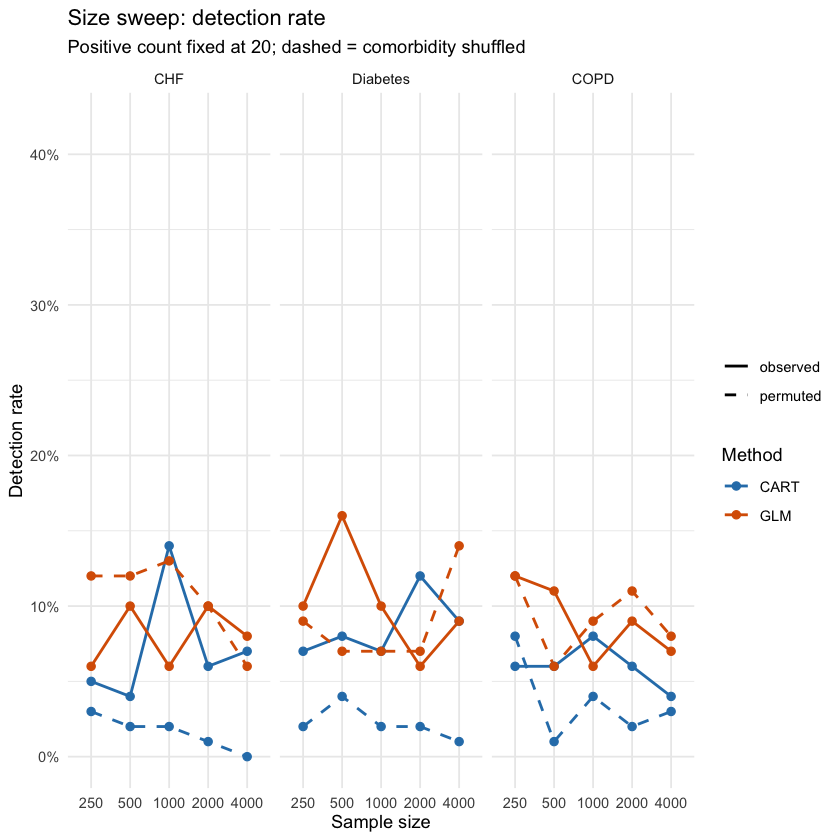

In [18]:
size_detect_long <- tree_size_rate %>%
  select(comorbidity, n_fixed, permute, CART = split_rate, GLM = glm_rate) %>%
  pivot_longer(c(CART, GLM), names_to = "method", values_to = "detect_rate") %>%
  mutate(comorbidity = factor(comorbidity, levels = c("chf", "diabetes", "copd"),
                              labels = c("CHF", "Diabetes", "COPD")))

p_size_detect <- ggplot(size_detect_long,
                        aes(x = factor(n_fixed), y = detect_rate,
                            color = method, linetype = permute,
                            group = interaction(method, permute))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  facet_wrap(~ comorbidity) +
  scale_y_continuous(limits = c(0, 0.42), labels = scales::percent) +
  scale_color_manual(values = c(CART = "#2c7fb8", GLM = "#d95f02")) +
  scale_linetype_manual(values = c("FALSE" = "solid", "TRUE" = "dashed"),
                        labels = c("FALSE" = "observed", "TRUE" = "permuted")) +
  labs(title = "Size sweep: detection rate",
       subtitle = "Positive count fixed at 20; dashed = comorbidity shuffled",
       x = "Sample size", y = "Detection rate",
       color = "Method", linetype = NULL) +
  theme_minimal()
p_size_detect

ggsave("../figures/tree_size_detect.png", p_size_detect,
       width = 6.5, height = 3.4, dpi = 150)


## Effect Size and Power

The sweep asks whether a 500-row subsample recovers the comorbidity x creatinine
interaction. That question only means something if the interaction exists, so it is
first estimated on the full pool, then the standard error is rescaled to n = 500 to
ask what detection rate statistical theory predicts. Comparing that prediction against
the detection rate the sweep actually produced shows whether the null result is a
property of the design or a symptom of something gone wrong.

In [19]:
full_interaction_test <- function(comorbidity_col, pool) {
  pool_num <- pool
  pool_num[[comorbidity_col]] <- as.numeric(as.character(pool_num[[comorbidity_col]]))

  f <- as.formula(paste0("hospital_expire_flag ~ anchor_age + creatinine_max_capped + ",
                         comorbidity_col, " + ", comorbidity_col, ":creatinine_max_capped"))
  fit <- suppressWarnings(glm(f, data = pool_num, family = binomial))

  cf   <- coef(summary(fit))
  term <- grep(paste0("^(creatinine_max_capped:", comorbidity_col, "|",
                      comorbidity_col, ":creatinine_max_capped)$"),
               rownames(cf), value = TRUE)

  data.frame(
    comorbidity = comorbidity_col,
    estimate    = cf[term, "Estimate"],
    std_error   = cf[term, "Std. Error"],
    z           = cf[term, "z value"],
    p           = cf[term, "Pr(>|z|)"],
    row.names   = NULL
  )
}

full_fit <- bind_rows(lapply(c("chf", "diabetes", "copd"), full_interaction_test, pool = pool))
print(full_fit)

  comorbidity    estimate  std_error         z            p
1         chf -0.04967182 0.01281610 -3.875736 1.063029e-04
2    diabetes -0.07092390 0.01263895 -5.611534 2.005411e-08
3        copd  0.06680412 0.01968505  3.393647 6.896843e-04


In [20]:
N_SUB   <- 500                    # rows per replicate throughout the sweep
ALPHA   <- 0.05
Z_CRIT  <- qnorm(1 - ALPHA / 2)   # 1.96
Z_POWER <- qnorm(0.80)            # 0.84, used for the "n needed for 80% power" column

glm_observed <- tree_results %>%
  group_by(comorbidity, permute) %>%
  summarise(rate = mean(glm_p < 0.05, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = permute, values_from = rate, names_prefix = "glm_")

power_table <- full_fit %>%
  mutate(
    n_full    = nrow(pool),
    # SE scales as 1/sqrt(n). This ignores the deliberate enrichment of positives at
    # high k, which makes those subsamples somewhat more efficient than assumed here,
    # so the predicted power below is a mild under-estimate.
    se_500    = std_error * sqrt(n_full / N_SUB),
    z_500     = abs(estimate) / se_500,
    power_500 = pnorm(Z_CRIT - z_500, lower.tail = FALSE) + pnorm(-Z_CRIT - z_500),
    n_for_80  = ceiling(n_full * (std_error * (Z_CRIT + Z_POWER) / abs(estimate))^2)
  ) %>%
  left_join(glm_observed, by = "comorbidity") %>%
  transmute(
    comorbidity,
    est_full  = round(estimate, 4),
    se_full   = round(std_error, 4),
    p_full    = signif(p, 3),
    se_500    = round(se_500, 3),
    z_500     = round(z_500, 2),
    power_500 = round(power_500, 3),   # theory: expected detection rate at n = 500
    obs_glm   = round(glm_FALSE, 3),   # what the sweep produced
    obs_null  = round(glm_TRUE,  3),   # permutation false-positive floor
    n_for_80
  )

print(power_table)   # base data.frame: width = Inf is a tibble-only argument

  comorbidity est_full se_full   p_full se_500 z_500 power_500 obs_glm obs_null
1         chf  -0.0497  0.0128 1.06e-04  0.153  0.33     0.062   0.067    0.066
2    diabetes  -0.0709  0.0126 2.01e-08  0.151  0.47     0.076   0.074    0.079
3        copd   0.0668  0.0197 6.90e-04  0.234  0.28     0.059   0.101    0.073
  n_for_80
1    37075
2    17686
3    48357
